In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
RANDOM_STATE = 42

In [4]:
n_samples = 1000

In [20]:
np.random.seed(RANDOM_STATE)

t = np.linspace(0, 10, 1000)
T = 1
sin = np.sin(2 * np.pi * t / T)
trend = t * 0.5
noise = np.random.randn(n_samples) * 0.5
y = trend + sin + noise

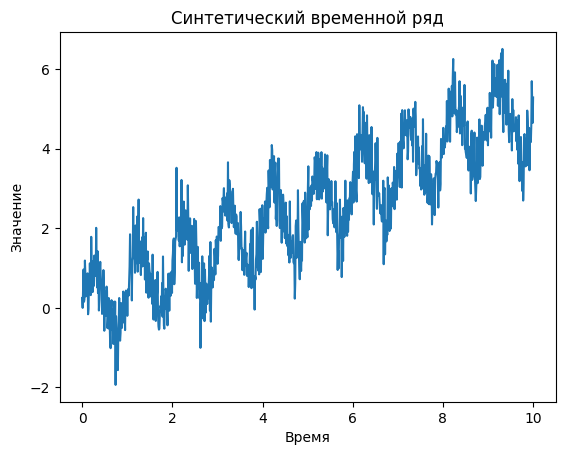

In [21]:
plt.plot(t, y)
plt.xlabel('Время')
plt.ylabel('Значение')
plt.title('Синтетический временной ряд')
plt.show()

In [25]:
train_size =int(n_samples * 0.8)

In [26]:
X_train, y_train, X_test, y_test = t[:train_size], y[:train_size], t[train_size:], y[train_size:]

In [50]:
def select_lag_by_aic(series, max_lag=200):
    best_aic = np.inf
    best_lag = 0
    for lag in range(1, max_lag + 1):
        model = AutoReg(series, lags=lag)
        res = model.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_lag = lag
    return best_lag, best_aic

In [65]:
best_lag, _ = select_lag_by_aic(y_train)
ar = AutoReg(y_train, lags=best_lag)
ar = ar.fit()
y_pred_ar = ar.predict(start=len(y_train), end = n_samples-1)

In [66]:
mae_ar = mean_absolute_error(y_test, y_pred_ar)
rmse_ar = np.sqrt(mean_squared_error(y_test, y_pred_ar))

In [67]:
print(f"MAE = {mae_ar:.4f}, RMSE = {rmse_ar:.4f}")

MAE = 0.4312, RMSE = 0.5384


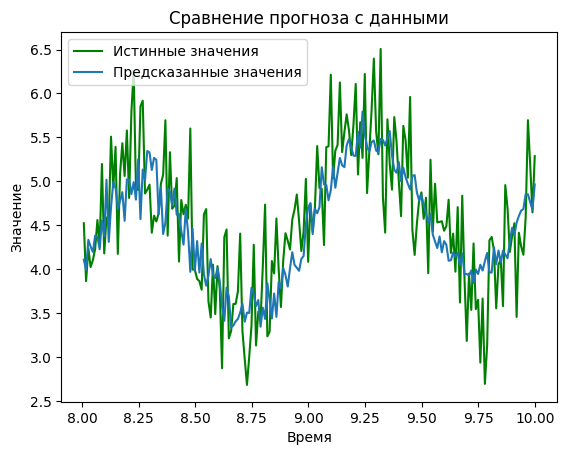

In [59]:
plt.plot(X_test, y_test, c='green', label='Истинные значения')
plt.plot(X_test, y_pred_ar, label='Предсказанные значения')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.title('Сравнение прогноза с данными')
plt.legend()
plt.show()

In [75]:
best_aic = np.inf
best_period = None
for period in range(2, 200):
    try:
        model = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=period)
        fit = model.fit()
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_period = period
    except:
        continue

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_

Лучший период по AIC: 100


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [76]:
ets = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=best_period)
ets = ets.fit()
y_pred_ets = ets.forecast(len(y_test))

In [77]:
mae_ets = mean_absolute_error(y_test, y_pred_ets)
rmse_ets = np.sqrt(mean_squared_error(y_test, y_pred_ets))

In [78]:
print(f"MAE = {mae_ets:.4f}, RMSE = {rmse_ets:.4f}")

MAE = 0.4032, RMSE = 0.5090


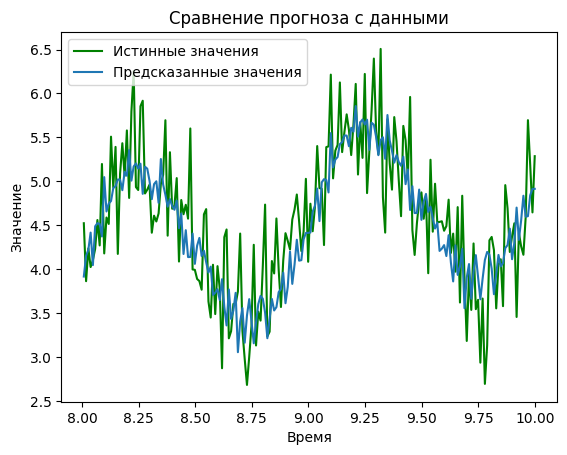

In [79]:
plt.plot(X_test, y_test, c='green', label='Истинные значения')
plt.plot(X_test, y_pred_ets, label='Предсказанные значения')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.title('Сравнение прогноза с данными')
plt.legend()
plt.show()

# Выводы

1. Визуализация сгенерированных данных подтверждает наличие тренда и периодических колебаний.

2. Модель авторегрессии  
   - Оптимальный порядок лага выбран автоматически по критерию AIC (перебор до 200 лагов).  
   - Результаты на тестовой выборке:  
     - MAE = 0.4312
     - RMSE = 0.5384
   - Прогноз AR хорошо передаёт общий тренд.

3. Модель экспоненциального сглаживания  
   - Период сезонности также определён автоматически перебором по AIC (выбран период = 100).  
   - Результаты на тестовой выборке:
     - MAE = 0.4032  
     - RMSE = 0.5090
   - ETS точнее отслеживает синусоидальную компоненту, что подтверждается меньшими значениями метрик по сравнению с AR.

4. Визуализация прогнозов

   Графики сравнения прогнозов с истинными значениями показывают, что обе модели адекватно следуют за трендом, но ETS даёт более точные предсказания в пиковых точках, что подтверждается метриками.
